In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load the original split files
train_df = pd.read_csv('/kaggle/input/banking-dataset-marketing-targets/train.csv', sep=';')
test_df = pd.read_csv('/kaggle/input/banking-dataset-marketing-targets/test.csv', sep=';')

print("Data Loaded.")
train_df.head()

Data Loaded.


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [4]:
train_df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [5]:
# CATEGORICAL COLUMNS ANALYSIS
categorical_cols = train_df.select_dtypes(include=['object']).columns
categorical_cols   

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'y'],
      dtype='object')

In [6]:
for col in categorical_cols:
    unique_vals=train_df[col].unique()
    print(f"\nUnique values in '{col}' ({len(unique_vals)} total):")
    print(unique_vals)


Unique values in 'job' (12 total):
['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']

Unique values in 'marital' (3 total):
['married' 'single' 'divorced']

Unique values in 'education' (4 total):
['tertiary' 'secondary' 'unknown' 'primary']

Unique values in 'default' (2 total):
['no' 'yes']

Unique values in 'housing' (2 total):
['yes' 'no']

Unique values in 'loan' (2 total):
['no' 'yes']

Unique values in 'contact' (3 total):
['unknown' 'cellular' 'telephone']

Unique values in 'month' (12 total):
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']

Unique values in 'poutcome' (4 total):
['unknown' 'failure' 'other' 'success']

Unique values in 'y' (2 total):
['no' 'yes']


In [7]:
train_df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [8]:
initial_shape = train_df.shape
train_df = train_df.drop_duplicates()
final_shape = train_df.shape
print(f"Removed {initial_shape[0]- final_shape[0]} duplicate rows.")

Removed 0 duplicate rows.


In [9]:
#All categorical columns have been stripped of extra spaces
for col in categorical_cols:
    train_df[col]=train_df[col].str.strip()
    test_df[col] = test_df[col].str.strip()

In [10]:
train_df = train_df[train_df['balance'] >0]
test_df = test_df[test_df['balance'] >0]

In [11]:
train_df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,37931.000000,37931.000000,37931.000000,37931.000000,37931.000000,37931.000000,37931.000000
mean,40.985025,1655.270254,15.695790,259.879386,2.718542,41.976510,0.615091
std,10.762390,3240.126649,8.283239,259.235650,2.988197,101.584743,2.419962
min,18.000000,1.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,226.500000,8.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,644.000000,16.000000,181.000000,2.000000,-1.000000,0.000000
75%,49.000000,1776.000000,21.000000,322.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [12]:
train_df[train_df['balance']==1]
train_df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [13]:
# Function to inspect each column deeply
def inspect_columns(df):
    print(f"{'Column':<15} | {'Min':<10} | {'Max':<10} | {'Unique Count':<12} | {'Top Value'}")
    print("-" * 70)
    
    for col in df.columns:
        # For numerical columns, show min/max
        if df[col].dtype in ['int64', 'float64']:
            min_val = df[col].min()
            max_val = df[col].max()
            unique_count = df[col].nunique()
            top_val = "N/A" # Not very useful for continuous numbers
        # For categorical columns, show top value
        else:
            min_val = "N/A"
            max_val = "N/A"
            unique_count = df[col].nunique()
            top_val = df[col].mode()[0]
            
        print(f"{col:<15} | {min_val:<10} | {max_val:<10} | {unique_count:<12} | {top_val}")

# Run the inspection
inspect_columns(train_df)

Column          | Min        | Max        | Unique Count | Top Value
----------------------------------------------------------------------
age             | 18         | 95         | 77           | N/A
job             | N/A        | N/A        | 12           | management
marital         | N/A        | N/A        | 3            | married
education       | N/A        | N/A        | 4            | secondary
default         | N/A        | N/A        | 2            | no
balance         | 1          | 102127     | 6251         | N/A
housing         | N/A        | N/A        | 2            | yes
loan            | N/A        | N/A        | 2            | no
contact         | N/A        | N/A        | 3            | cellular
day             | 1          | 31         | 31           | N/A
month           | N/A        | N/A        | 12           | may
duration        | 0          | 4918       | 1526         | N/A
campaign        | 1          | 63         | 48           | N/A
pdays           | -1 

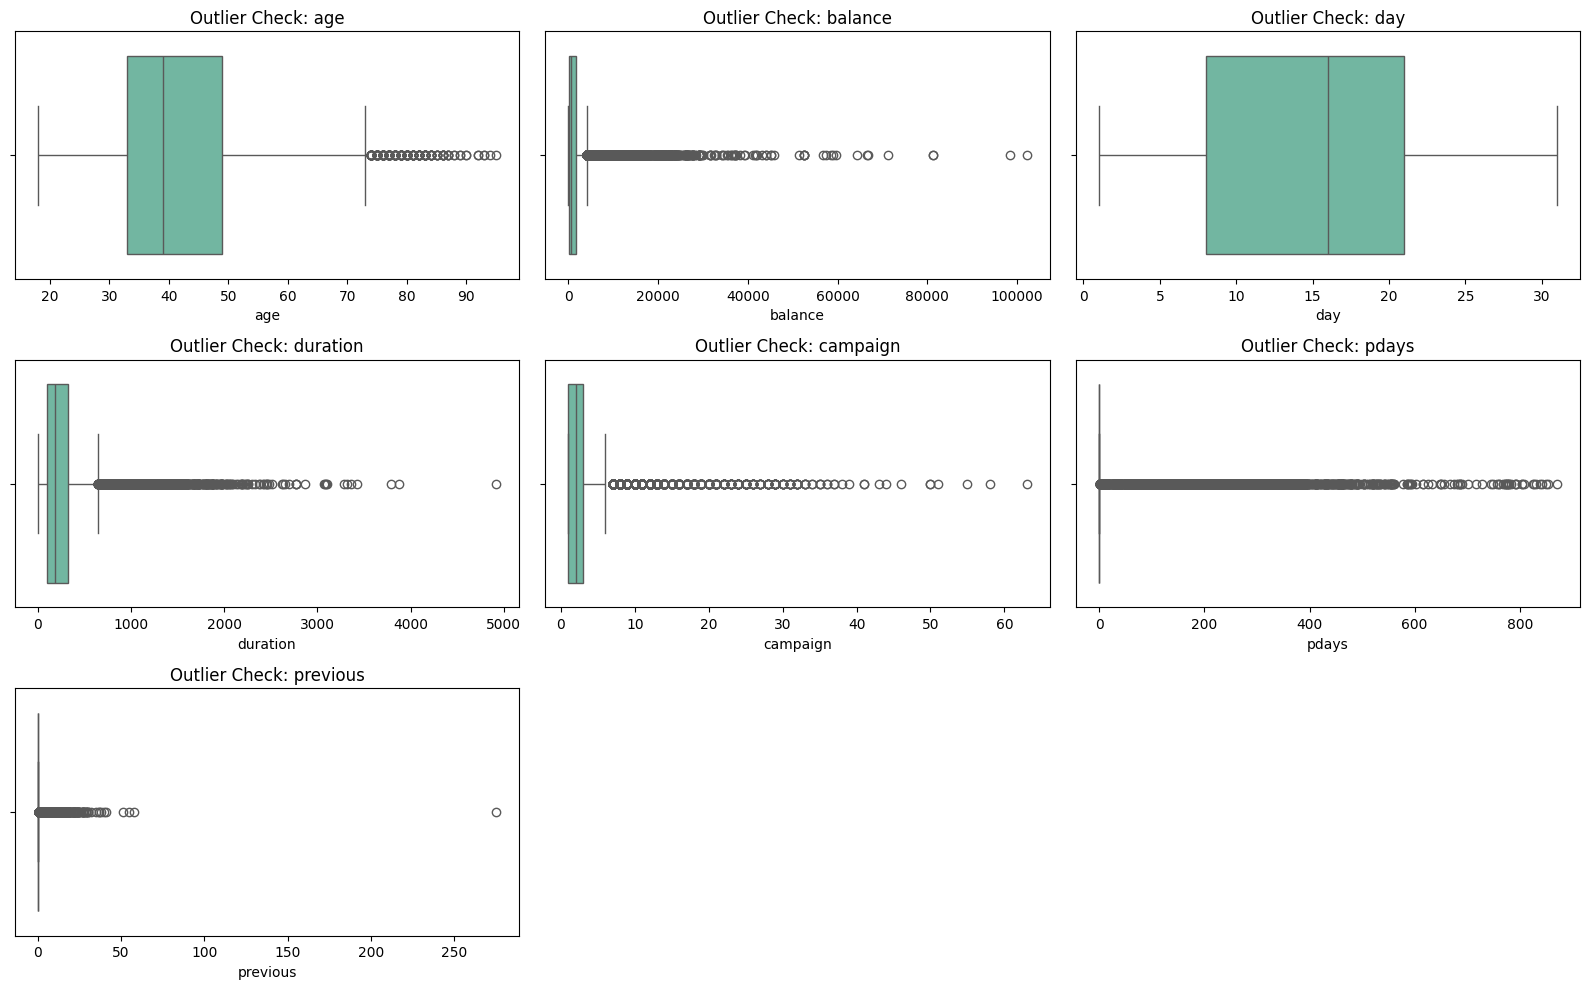

In [14]:
# Visualizing Outliers for Numerical Columns
numerical_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

plt.figure(figsize=(16, 10))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=train_df[col], palette='Set2')
    plt.title(f'Outlier Check: {col}')

plt.tight_layout()
plt.show()

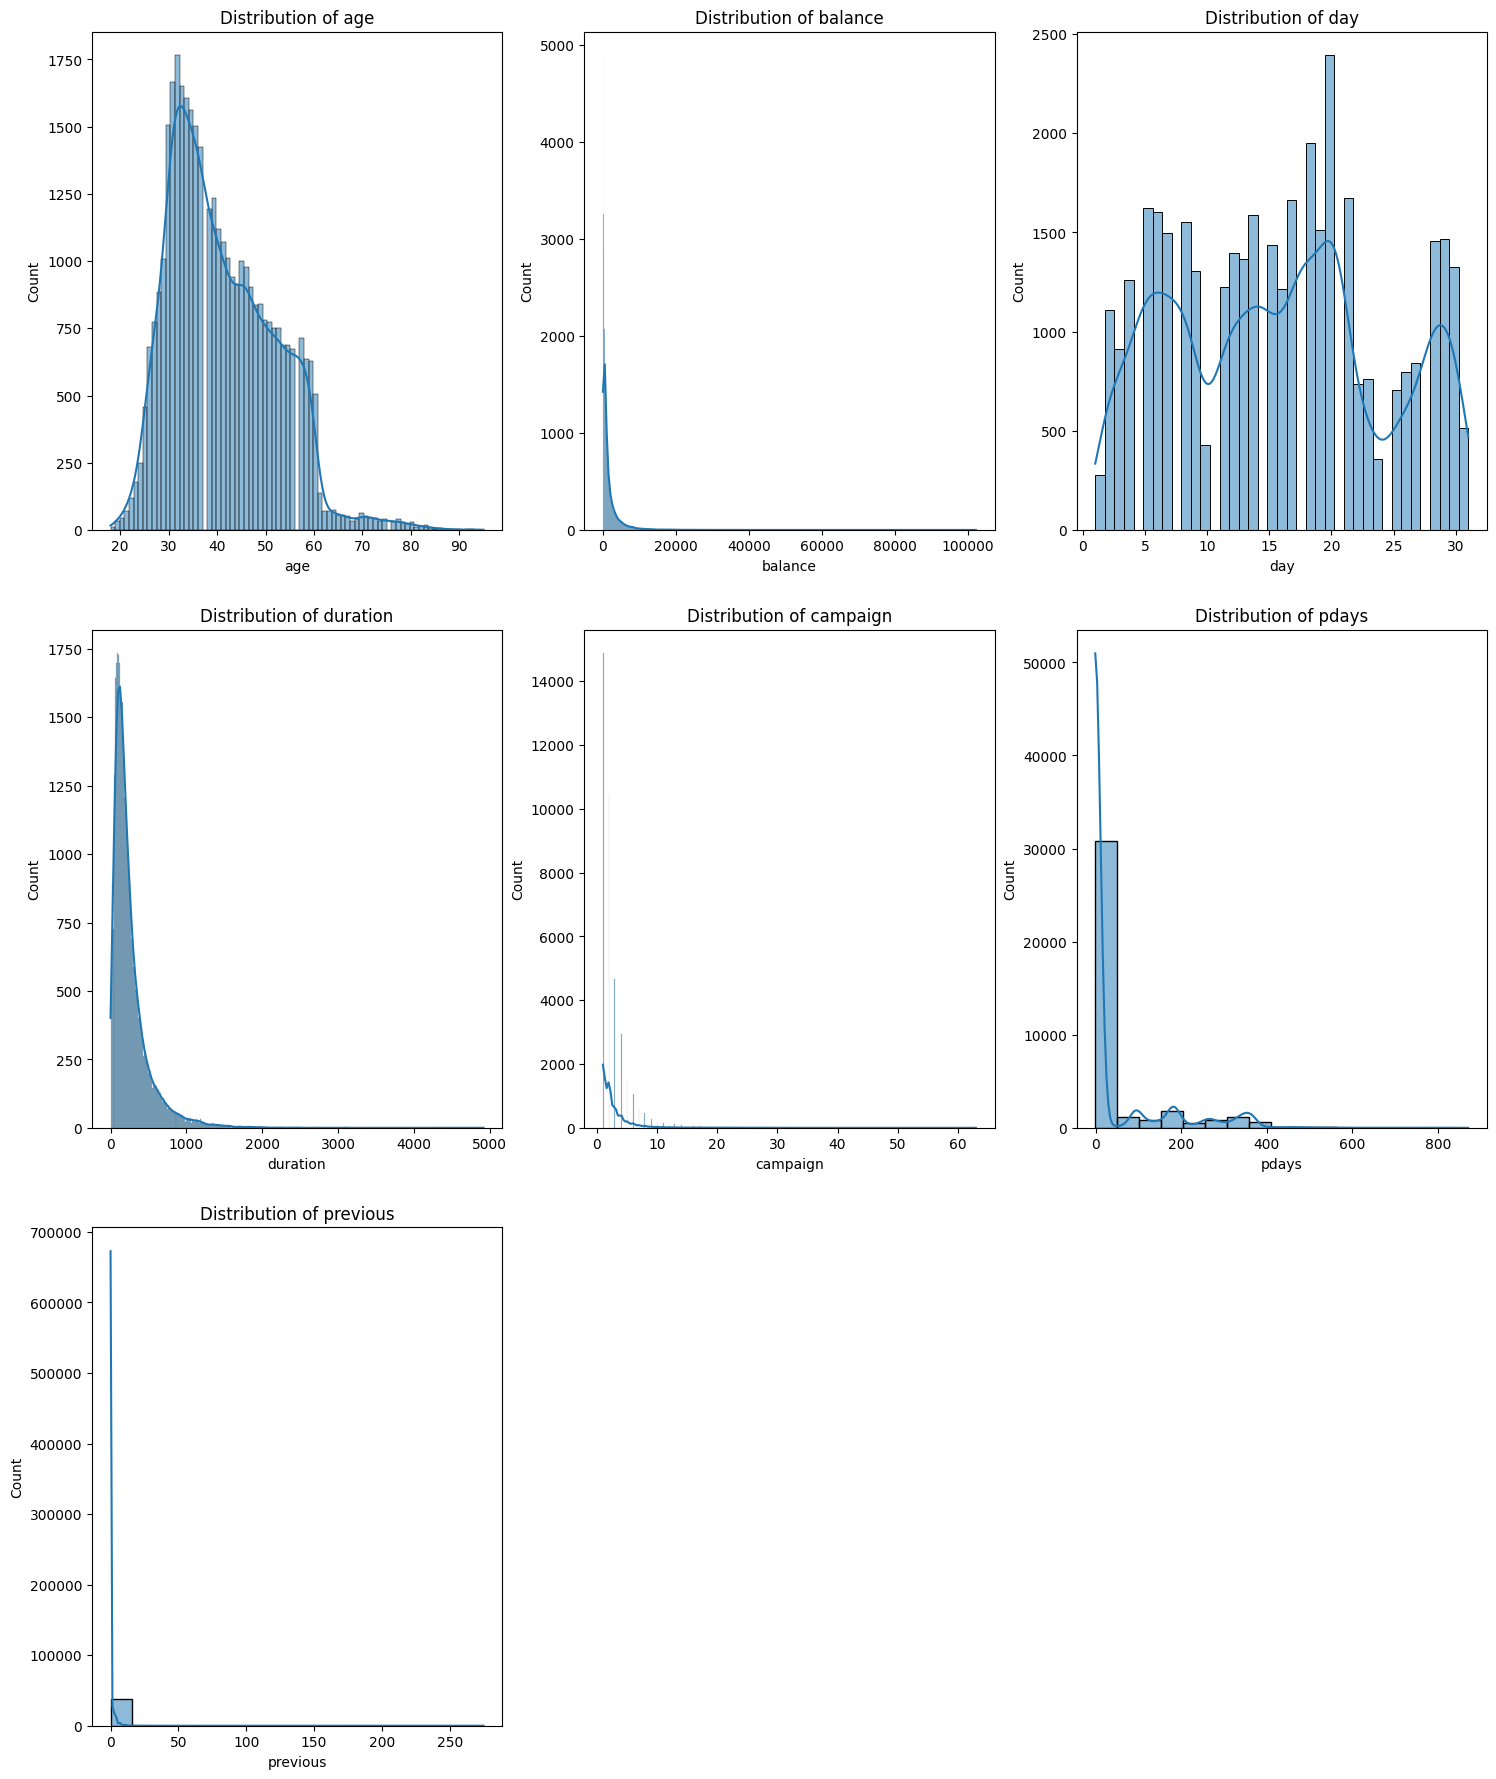

In [15]:
# Distribution of Numerical Features
plt.figure(figsize=(18,22))
for i, col in enumerate (numerical_cols,1):
    plt.subplot(3,3,i)
    sns.histplot(train_df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout
plt.show()


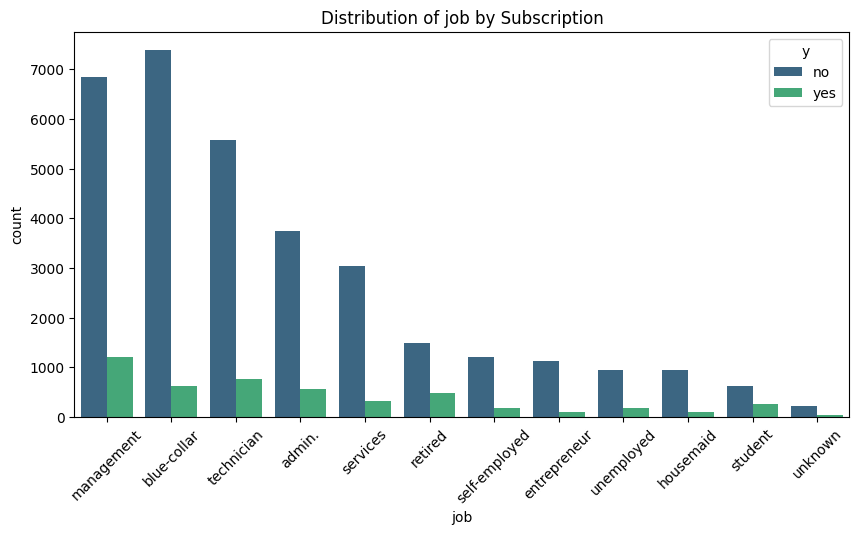

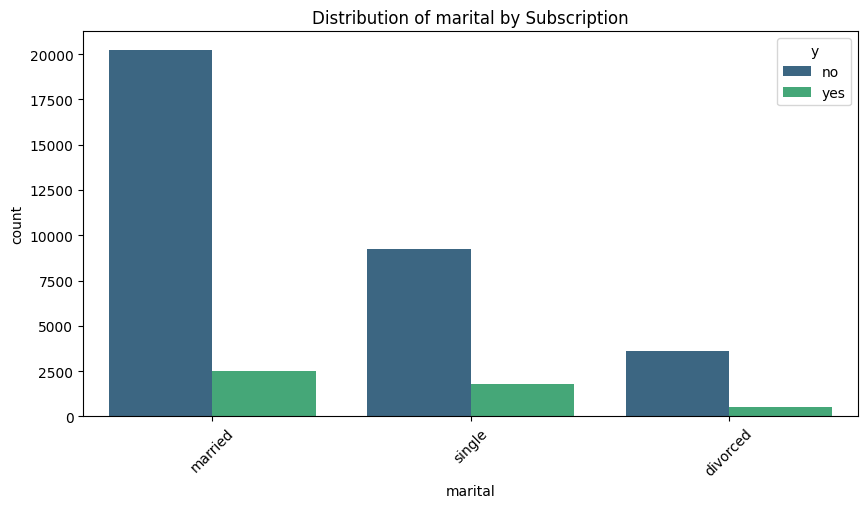

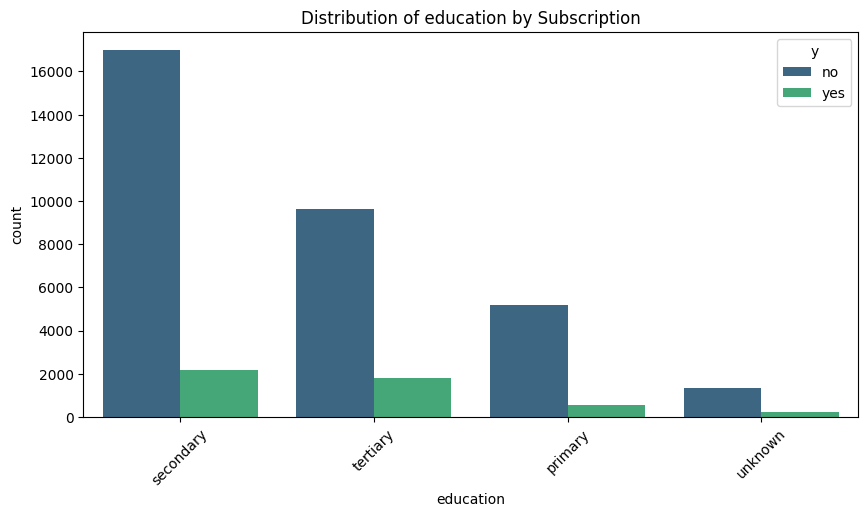

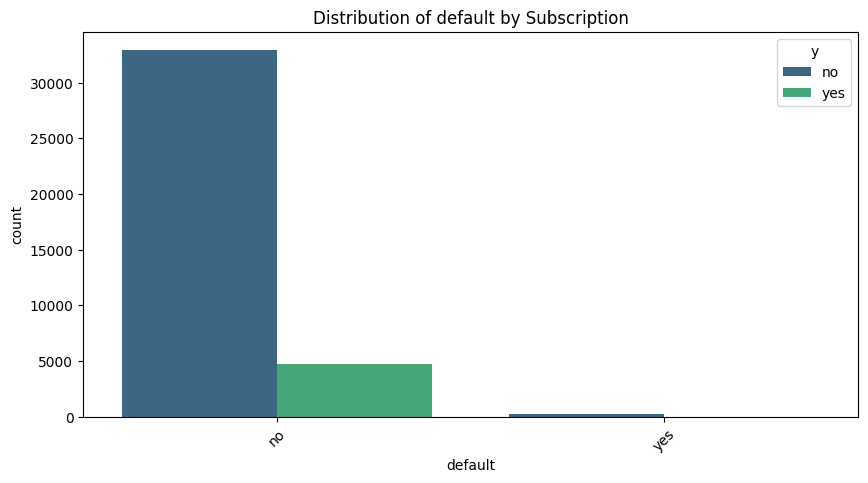

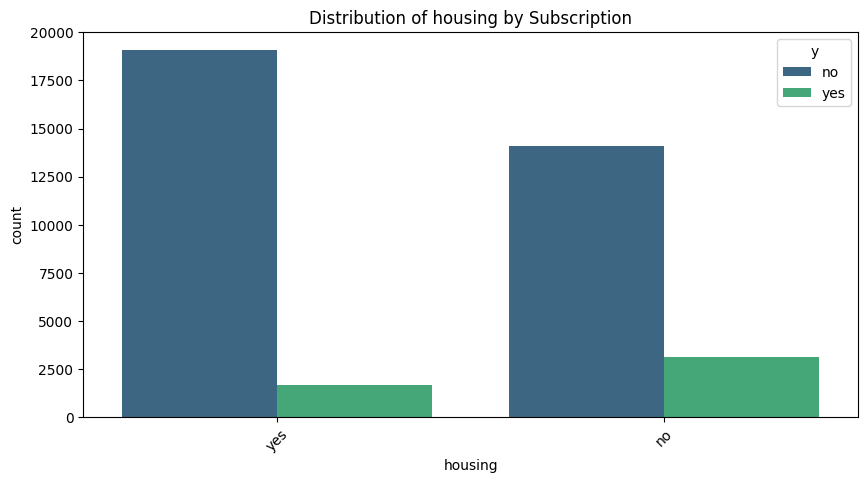

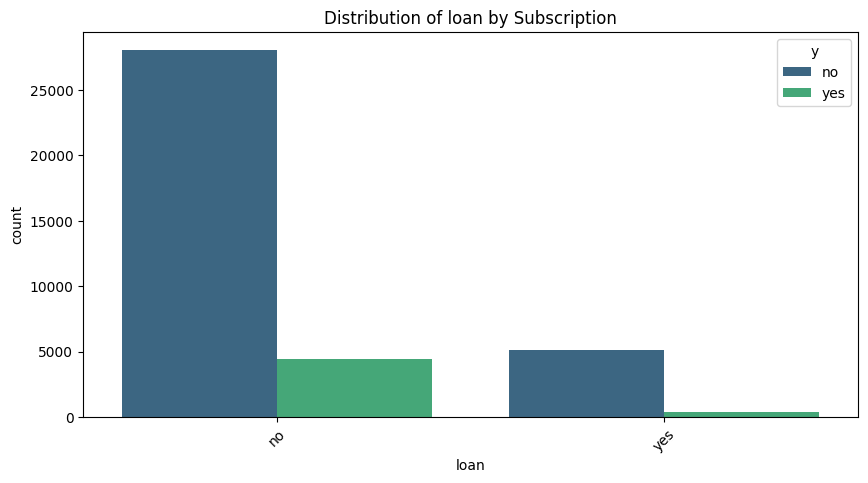

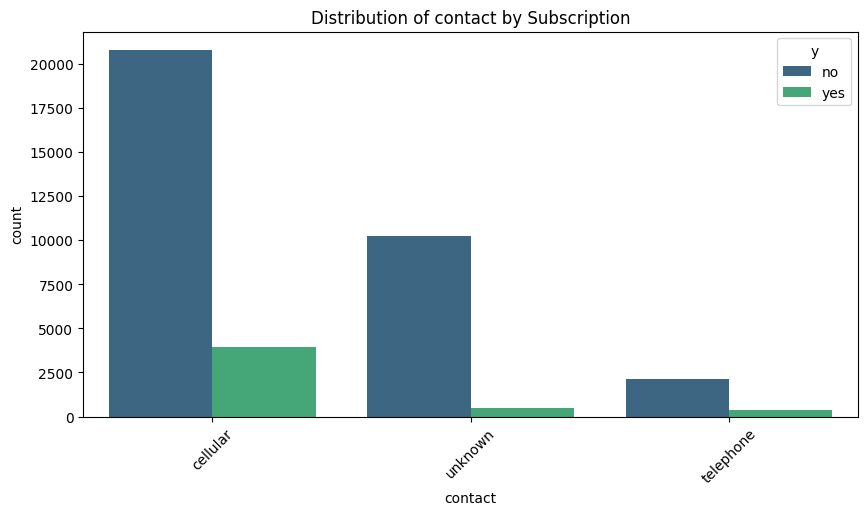

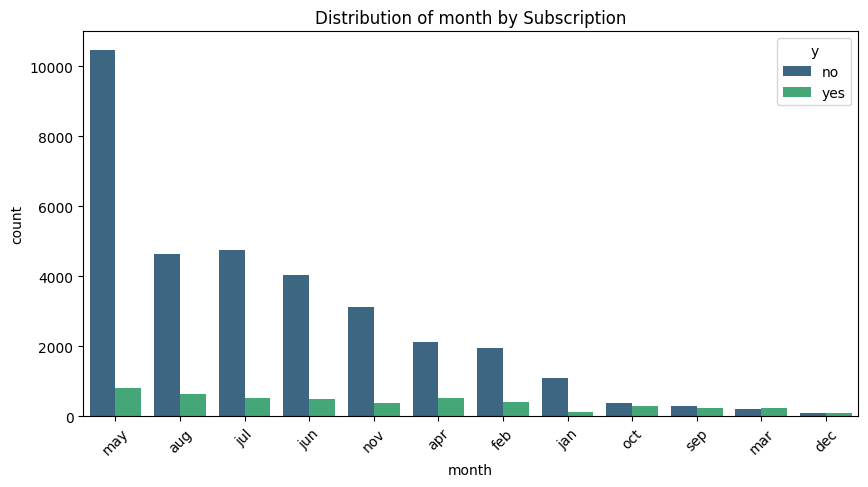

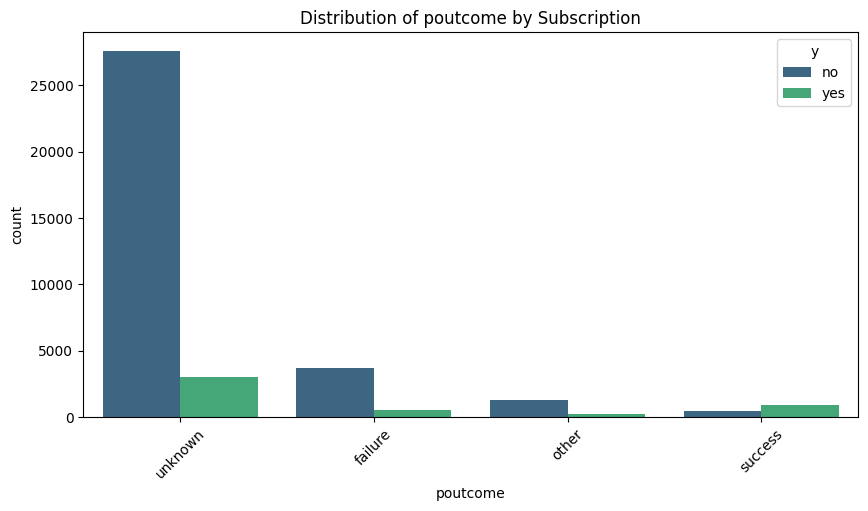

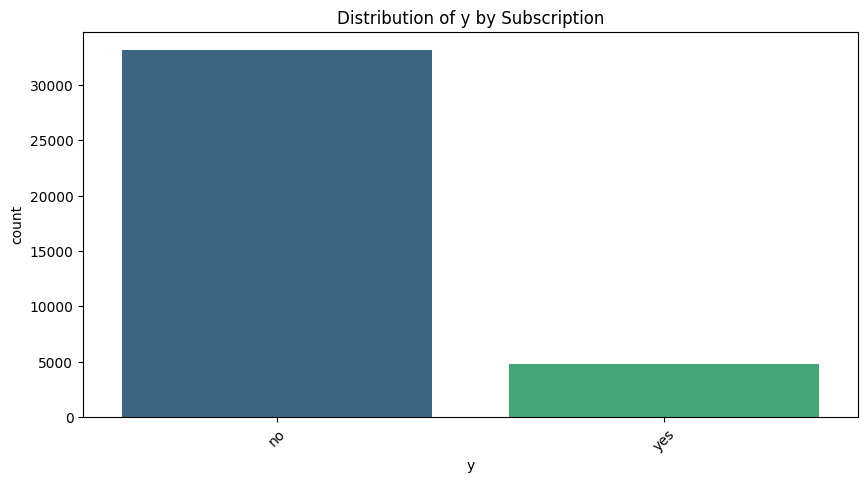

In [16]:
#Visualizing Categorical Distributions
for col in categorical_cols:
    plt.figure(figsize=(10,5))
    # 'y' is our target, we color by it to see the success rate directly
    sns.countplot(data=train_df, x=col, hue='y', palette='viridis', order=train_df[col].value_counts().index)
    plt.title(f'Distribution of {col} by Subscription')
    plt.xticks(rotation=45)
    plt.show()

In [17]:
#DROPPING UNNECESSARY COLUMNS
# 'default' has very low variance, it doesn't help the model
train_df=train_df.drop(columns=['default'])
test_df = test_df.drop(columns=['default'])

In [18]:
#HANDLING 'UNKNOWN' VALUES
# For 'job' and 'education', 'unknown' is common. 
# Instead of deleting, let's keep them as a separate category 
# because "not knowing the job" might be a pattern itself.
# We already stripped spaces, so they are cleanly labeled as 'unknown'.

In [19]:
#LOG TRANSFORMATION (Handling Skewness in 'balance')
# Since balance has many outliers, we use log transformation to normalize it.
# We add a small constant (1) because log(0) is undefined.
train_df['balance_log'] = np.log1p(train_df['balance'])
test_df['balance_log'] = np.log1p(test_df['balance'])

In [20]:
train_df.head()

,age,job,marital,education,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,balance_log
0,58,management,married,tertiary,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,7.670429
1,44,technician,single,secondary,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,3.401197
2,33,entrepreneur,married,secondary,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,1.098612
3,47,blue-collar,married,unknown,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,7.317876
4,33,unknown,single,unknown,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,0.693147


In [21]:
# Drop the old balance to avoid redundancy
train_df=train_df.drop(columns=['balance'])
test_df=test_df.drop(columns=['balance'])

# Dropping 'day' column as it adds more noise than signal
train_df = train_df.drop(columns=['day'])
test_df = test_df.drop(columns=['day'])

In [22]:
train_df['duration_log'] = np.log1p(train_df['duration'])
test_df['duration_log'] = np.log1p(test_df['duration'])

# Drop the old duration column
train_df = train_df.drop(columns=['duration'])
test_df = test_df.drop(columns=['duration'])

In [23]:
train_df.head()

,age,job,marital,education,housing,loan,contact,month,campaign,pdays,previous,poutcome,y,balance_log,duration_log
0,58,management,married,tertiary,yes,no,unknown,may,1,-1,0,unknown,no,7.670429,5.568345
1,44,technician,single,secondary,yes,no,unknown,may,1,-1,0,unknown,no,3.401197,5.023881
2,33,entrepreneur,married,secondary,yes,yes,unknown,may,1,-1,0,unknown,no,1.098612,4.343805
3,47,blue-collar,married,unknown,yes,no,unknown,may,1,-1,0,unknown,no,7.317876,4.532599
4,33,unknown,single,unknown,no,no,unknown,may,1,-1,0,unknown,no,0.693147,5.293305


In [24]:
# ENCODING STRATEGY

In [25]:
# Grouping 'job' into broader categories
#Ordinal Encoding for 'education'
education_map={"unknown": 0,
               "primary":1,
               "secondary":2,
               'tertiary': 3}
train_df['education_ordinal']= train_df['education'].map(education_map)
test_df['education_ordinal'] = test_df['education'].map(education_map)

In [26]:
# Grouping 'job' into broader categories
job_map = {
    'management': 'white-collar', 'admin.': 'white-collar', 'entrepreneur': 'white-collar', 'self-employed': 'white-collar',
    'blue-collar': 'blue-collar', 'services': 'blue-collar', 'technician': 'blue-collar', 'housemaid': 'blue-collar',
    'retired': 'others', 'student': 'others', 'unemployed': 'others', 'unknown': 'others'}
train_df['job_grouped'] = train_df['job'].map(job_map)
test_df['job_grouped'] = test_df['job'].map(job_map)

In [27]:
# Dropping old columns
cols_to_drop=['education', 'job']
train_df = train_df.drop(columns=cols_to_drop)
test_df=test_df.drop(columns=cols_to_drop)

In [28]:
train_df.head()

,age,marital,housing,loan,contact,month,campaign,pdays,previous,poutcome,y,balance_log,duration_log,education_ordinal,job_grouped
0,58,married,yes,no,unknown,may,1,-1,0,unknown,no,7.670429,5.568345,3,white-collar
1,44,single,yes,no,unknown,may,1,-1,0,unknown,no,3.401197,5.023881,2,blue-collar
2,33,married,yes,yes,unknown,may,1,-1,0,unknown,no,1.098612,4.343805,2,white-collar
3,47,married,yes,no,unknown,may,1,-1,0,unknown,no,7.317876,4.532599,0,blue-collar
4,33,single,no,no,unknown,may,1,-1,0,unknown,no,0.693147,5.293305,0,others


In [29]:
# One-Hot Encoding for remaining manageable columns
# We use marital, contact, poutcome, month, and our new job_grouped
final_cat_cols = ['marital', 'contact', 'month', 'poutcome', 'job_grouped']
train_df = pd.get_dummies(train_df, columns=final_cat_cols, drop_first=True)
test_df = pd.get_dummies(test_df, columns=final_cat_cols, drop_first=True)

In [30]:
# Synchronize train and test columns
train_df, test_df = train_df.align(test_df, join='inner', axis=1)

In [31]:
print(f"Refined encoding complete. Final columns: {len(train_df.columns)}")

Refined encoding complete. Final columns: 30


In [32]:
# Check for unique values and missing data across all columns
def final_data_check(df):
    print(f"{'Column Name':<25} | {'Type':<10} | {'NaN Count':<10} | {'Unique Sample / Range'}")
    print("-" * 85)

    for col in df.columns:
        dtype=str(df[col].dtype)
        nan_count=df[col].isnull().sum()

        if df[col].dtype == 'object' or df[col].nunique() < 15:
            # Show actual unique values for categorical or low-cardinality numbers
            sample = list(df[col].unique())[:5] # Showing first 5 unique values
        else:
            # Show range for numerical data
            sample = f"Min: {df[col].min():.2f}, Max: {df[col].max():.2f}"
        
        print(f"{col:<25} | {dtype:<10} | {nan_count:<10} | {sample}")

In [33]:
final_data_check(train_df)

Column Name               | Type       | NaN Count  | Unique Sample / Range
-------------------------------------------------------------------------------------
age                       | int64      | 0          | Min: 18.00, Max: 95.00
housing                   | object     | 0          | ['yes', 'no']
loan                      | object     | 0          | ['no', 'yes']
campaign                  | int64      | 0          | Min: 1.00, Max: 63.00
pdays                     | int64      | 0          | Min: -1.00, Max: 871.00
previous                  | int64      | 0          | Min: 0.00, Max: 275.00
y                         | object     | 0          | ['no', 'yes']
balance_log               | float64    | 0          | Min: 0.69, Max: 11.53
duration_log              | float64    | 0          | Min: 0.00, Max: 8.50
education_ordinal         | int64      | 0          | [np.int64(3), np.int64(2), np.int64(0), np.int64(1)]
marital_married           | bool       | 0          | [np.True_, np.

In [34]:
train_df.head()

,age,housing,loan,campaign,pdays,previous,y,balance_log,duration_log,education_ordinal,...,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown,job_grouped_others,job_grouped_white-collar
0,58,yes,no,1,-1,0,no,7.670429,5.568345,3,...,False,True,False,False,False,False,False,True,False,True
1,44,yes,no,1,-1,0,no,3.401197,5.023881,2,...,False,True,False,False,False,False,False,True,False,False
2,33,yes,yes,1,-1,0,no,1.098612,4.343805,2,...,False,True,False,False,False,False,False,True,False,True
3,47,yes,no,1,-1,0,no,7.317876,4.532599,0,...,False,True,False,False,False,False,False,True,False,False
4,33,no,no,1,-1,0,no,0.693147,5.293305,0,...,False,True,False,False,False,False,False,True,True,False


In [35]:
# Encoding Binary Categorical Variables
# Mapping 'yes' to 1 and 'no' to 0 for specific columns

binary_map= {'yes': 1, 'no': 0}
binary_cols = ['housing', 'loan', 'y']

for col in binary_cols:
    if col in train_df.columns:
        train_df[col]=train_df[col].map(binary_map)
        test_df[col]=test_df[col].map(binary_map)

In [36]:
train_df.head()

,age,housing,loan,campaign,pdays,previous,y,balance_log,duration_log,education_ordinal,...,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown,job_grouped_others,job_grouped_white-collar
0,58,1,0,1,-1,0,0,7.670429,5.568345,3,...,False,True,False,False,False,False,False,True,False,True
1,44,1,0,1,-1,0,0,3.401197,5.023881,2,...,False,True,False,False,False,False,False,True,False,False
2,33,1,1,1,-1,0,0,1.098612,4.343805,2,...,False,True,False,False,False,False,False,True,False,True
3,47,1,0,1,-1,0,0,7.317876,4.532599,0,...,False,True,False,False,False,False,False,True,False,False
4,33,0,0,1,-1,0,0,0.693147,5.293305,0,...,False,True,False,False,False,False,False,True,True,False


In [37]:
#Converting Boolean columns (from get_dummies) to Integer
# This converts True/False to 1/0
bool_cols = train_df.select_dtypes(include=['bool']).columns
train_df[bool_cols] = train_df[bool_cols].astype(int)
test_df[bool_cols] = test_df[bool_cols].astype(int)

In [38]:
train_df.head()

,age,housing,loan,campaign,pdays,previous,y,balance_log,duration_log,education_ordinal,...,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown,job_grouped_others,job_grouped_white-collar
0,58,1,0,1,-1,0,0,7.670429,5.568345,3,...,0,1,0,0,0,0,0,1,0,1
1,44,1,0,1,-1,0,0,3.401197,5.023881,2,...,0,1,0,0,0,0,0,1,0,0
2,33,1,1,1,-1,0,0,1.098612,4.343805,2,...,0,1,0,0,0,0,0,1,0,1
3,47,1,0,1,-1,0,0,7.317876,4.532599,0,...,0,1,0,0,0,0,0,1,0,0
4,33,0,0,1,-1,0,0,0.693147,5.293305,0,...,0,1,0,0,0,0,0,1,1,0


In [39]:
train_df.dtypes.value_counts()

int64      28
float64     2
Name: count, dtype: int64

In [40]:
# Calculate the correlation matrix
# Only including numeric columns for the correlation calculation
corr_matrix = train_df.corr()

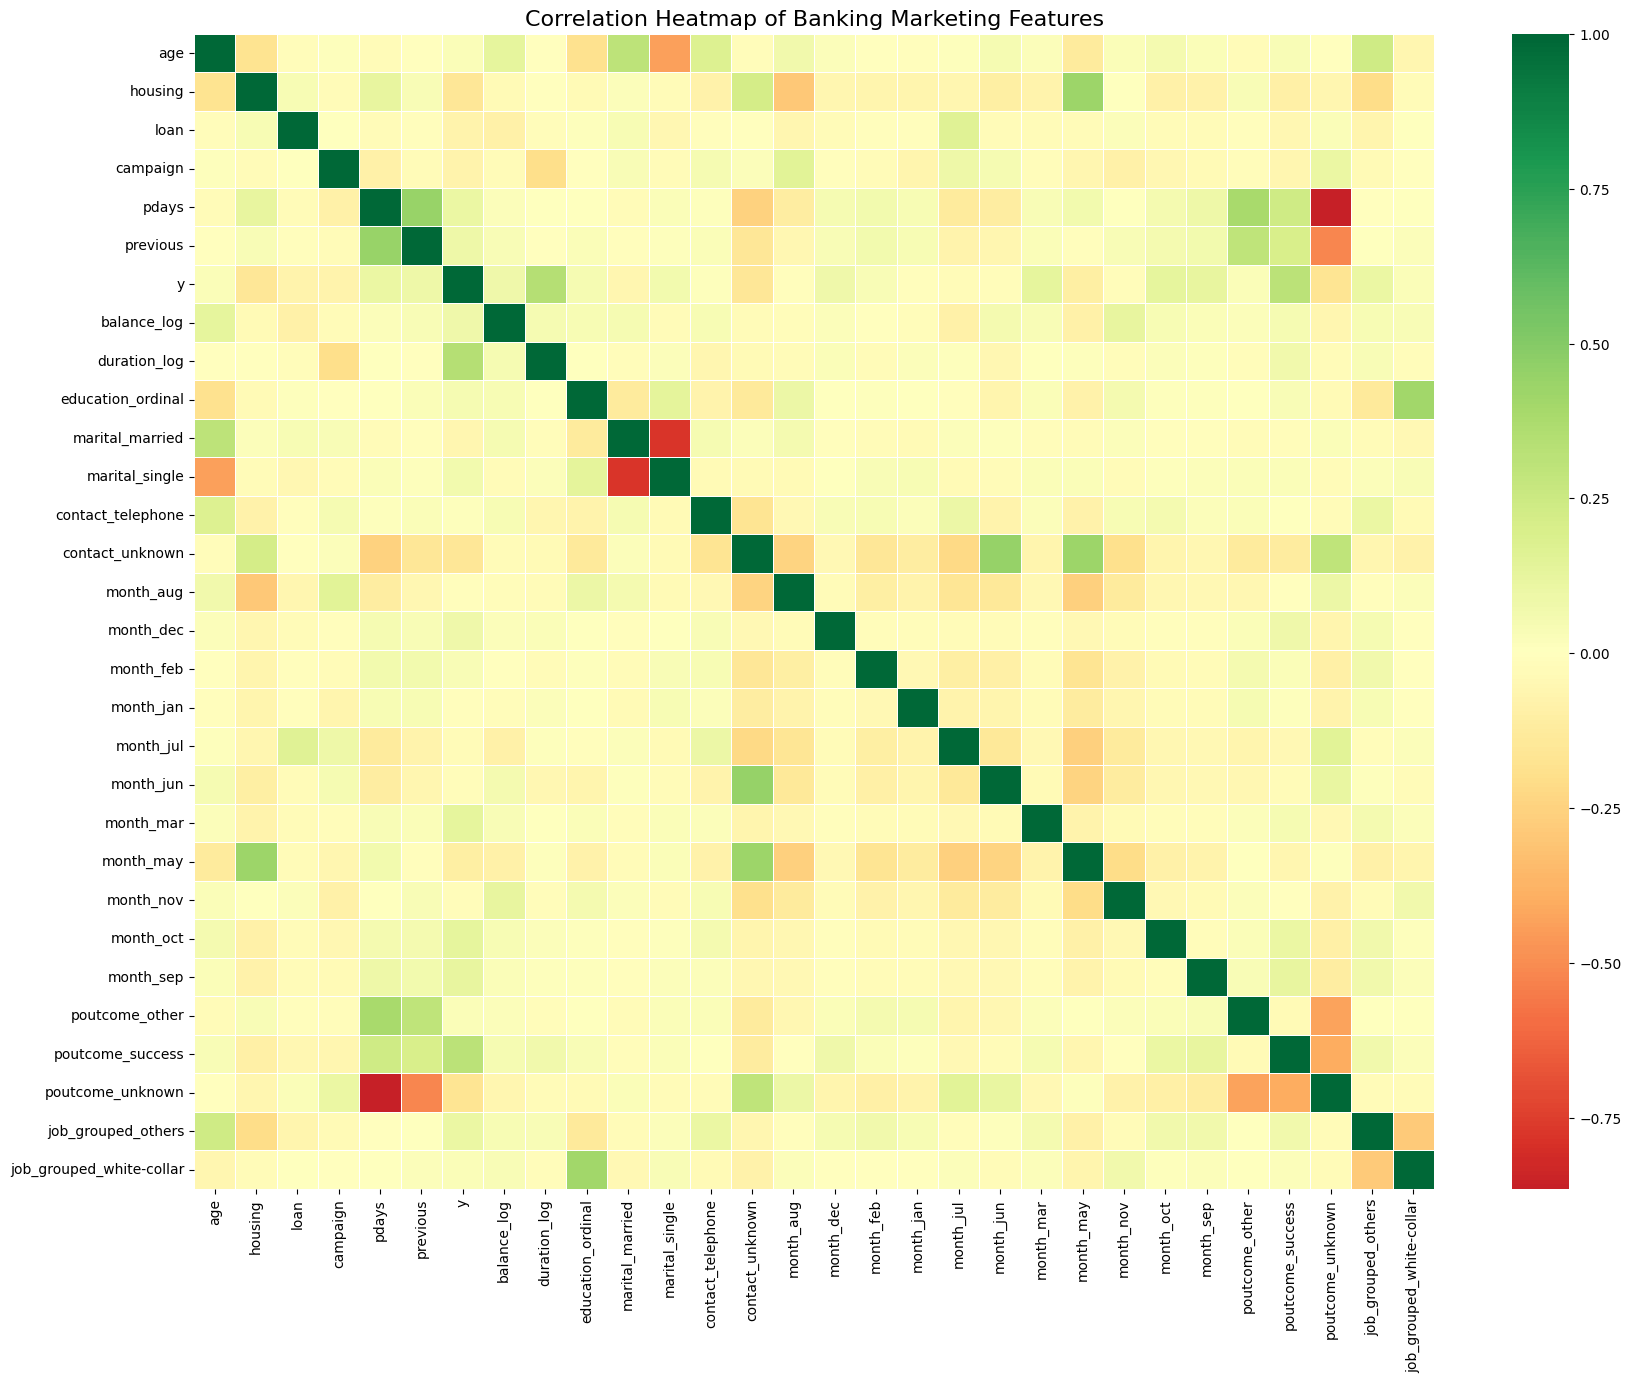

In [41]:
# Plotting the Heatmap
plt.figure(figsize=(20,15))
sns.heatmap(corr_matrix, annot=False, cmap='RdYlGn', center=0, linewidths=0.5)
plt.title('Correlation Heatmap of Banking Marketing Features', fontsize=16)
plt.show()

In [42]:
#Ranking features by their correlation with the target variable 'y'
target_correlation = corr_matrix['y'].sort_values(ascending=False)
print(target_correlation)

y                           1.000000
duration_log                0.344290
poutcome_success            0.312570
month_oct                   0.129855
month_mar                   0.129146
month_sep                   0.123451
job_grouped_others          0.106513
pdays                       0.104823
previous                    0.091746
month_dec                   0.078760
balance_log                 0.076460
marital_single              0.064680
education_ordinal           0.048731
month_feb                   0.036365
poutcome_other              0.031114
job_grouped_white-collar    0.025346
age                         0.025056
contact_telephone           0.015680
month_aug                  -0.006732
month_jan                  -0.010755
month_nov                  -0.018170
month_jun                  -0.019138
month_jul                  -0.031996
marital_married            -0.060671
loan                       -0.071376
campaign                   -0.076986
month_may                  -0.106776
h

In [43]:
from sklearn.preprocessing import StandardScaler
# Identify columns to scale
# Select ONLY truly numerical columns (not binary/dummy)
numeric_cols = ['age', 'campaign', 'pdays', 'previous', 'balance_log', 'duration_log']
scaler = StandardScaler()

#Fit and transform only these specific columns
train_df[numeric_cols] = scaler.fit_transform(train_df[numeric_cols])
test_df[numeric_cols] = scaler.transform(test_df[numeric_cols])


In [44]:
train_df.head()

,age,housing,loan,campaign,pdays,previous,y,balance_log,duration_log,education_ordinal,...,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown,job_grouped_others,job_grouped_white-collar
0,1.580987,1,0,-0.575117,-0.423066,-0.254177,0,0.799324,0.422947,3,...,0,1,0,0,0,0,0,1,0,1
1,0.280144,1,0,-0.575117,-0.423066,-0.254177,0,-1.759039,-0.167508,2,...,0,1,0,0,0,0,0,1,0,0
2,-0.741948,1,1,-0.575117,-0.423066,-0.254177,0,-3.138878,-0.905029,2,...,0,1,0,0,0,0,0,1,0,1
3,0.558896,1,0,-0.575117,-0.423066,-0.254177,0,0.588055,-0.700287,0,...,0,1,0,0,0,0,0,1,0,0
4,-0.741948,0,0,-0.575117,-0.423066,-0.254177,0,-3.381855,0.124675,0,...,0,1,0,0,0,0,0,1,1,0


In [45]:
#MODELS

In [46]:
# 1- Training Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 2 Prepare X and y
X_train = train_df.drop(columns=['y'])
y_train = train_df['y']

X_test = test_df.drop(columns=['y'])
y_test = test_df['y']

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [47]:
# 3. Make Predictions
y_pred_log = log_model.predict(X_test)

In [48]:
# 4. Evaluate the Model
print("--- Logistic Regression Performance ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_log):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

--- Logistic Regression Performance ---
Accuracy Score: 0.8976

Confusion Matrix:
[[3244   93]
 [ 296  165]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      3337
           1       0.64      0.36      0.46       461

    accuracy                           0.90      3798
   macro avg       0.78      0.67      0.70      3798
weighted avg       0.88      0.90      0.88      3798



In [49]:
from sklearn.ensemble import RandomForestClassifier
# 1. Initialize the Model
# n_estimators=100 (we are using 100 different trees)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
# 2. Train the Model
rf_model.fit(X_train, y_train)
# 3. Make Predictions
y_pred_rf = rf_model.predict(X_test)
# 4. Evaluate
print("--- Random Forest Performance ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

--- Random Forest Performance ---
Accuracy Score: 1.0000

Confusion Matrix:
[[3337    0]
 [   0  461]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3337
           1       1.00      1.00      1.00       461

    accuracy                           1.00      3798
   macro avg       1.00      1.00      1.00      3798
weighted avg       1.00      1.00      1.00      3798



In [50]:
#RandomForestClassifier: THERE IS CLEAR OVERFITTING!!!! THAT' S NOT GOOD! NOT CORRECT RESULT!

In [51]:
from xgboost import XGBClassifier
# 1. Initialize the Model
# n_estimators=100: Number of sequential trees
# learning_rate=0.1: Step size for each tree's contribution
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

# 2. Train the Model
xgb_model.fit(X_train, y_train)

# 3. Make Predictions
y_pred_xgb = xgb_model.predict(X_test)

# 4. Evaluate
print("--- XGBoost Performance ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_xgb):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

--- XGBoost Performance ---
Accuracy Score: 0.9234

Confusion Matrix:
[[3256   81]
 [ 210  251]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      3337
           1       0.76      0.54      0.63       461

    accuracy                           0.92      3798
   macro avg       0.85      0.76      0.80      3798
weighted avg       0.92      0.92      0.92      3798



In [52]:
from lightgbm import LGBMClassifier
# Initialize the model
lgbm_model = LGBMClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
# Train
lgbm_model.fit(X_train, y_train)
# Predict
y_pred_lgbm = lgbm_model.predict(X_test)
# Evaluate
print("--- LightGBM Performance ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_lgbm):.4f}")
print(confusion_matrix(y_test, y_pred_lgbm))
print(classification_report(y_test, y_pred_lgbm))

[LightGBM] [Info] Number of positive: 4787, number of negative: 33144
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005207 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 962
[LightGBM] [Info] Number of data points in the train set: 37931, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.126203 -> initscore=-1.934958
[LightGBM] [Info] Start training from score -1.934958
--- LightGBM Performance ---
Accuracy Score: 0.9226
[[3247   90]
 [ 204  257]]
              precision    recall  f1-score   support

           0       0.94      0.97      0.96      3337
           1       0.74      0.56      0.64       461

    accuracy                           0.92      3798
   macro avg       0.84      0.77      0.80      3798
weighted avg       0.92      0.92      0.92      3798



In [53]:
# APPLYING SMOTE TO BALANCE DATA
from imblearn.over_sampling import SMOTE
from collections import Counter

In [54]:
# Checking original distribution
print(f"Original dataset shape: {Counter(y_train)}")

Original dataset shape: Counter({0: 33144, 1: 4787})


In [55]:
# Initialize SMOTE
smote = SMOTE(random_state=42)
# Resample ONLY the training data
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Resampled dataset shape: {Counter(y_train_smote)}")

Resampled dataset shape: Counter({0: 33144, 1: 33144})


In [56]:
# Now we can retrain our best model (LightGBM) with this new data
lgbm_smote = LGBMClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
lgbm_smote.fit(X_train_smote, y_train_smote)

[LightGBM] [Info] Number of positive: 33144, number of negative: 33144
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005105 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1578
[LightGBM] [Info] Number of data points in the train set: 66288, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


LGBMClassifier(random_state=42)

In [57]:
# Predict on the ORIGINAL test set
y_pred_smote = lgbm_smote.predict(X_test)

In [58]:
# Evaluate
print("--- LightGBM Performance with SMOTE ---")
print(confusion_matrix(y_test, y_pred_smote))
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_smote)}")
print(classification_report(y_test, y_pred_smote))

--- LightGBM Performance with SMOTE ---
[[3071  266]
 [ 132  329]]
Accuracy Score: 0.8952080042127436
              precision    recall  f1-score   support

           0       0.96      0.92      0.94      3337
           1       0.55      0.71      0.62       461

    accuracy                           0.90      3798
   macro avg       0.76      0.82      0.78      3798
weighted avg       0.91      0.90      0.90      3798



In [59]:
# Feature importance Scores
importances = lgbm_smote.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

In [60]:
feature_importance_df

,Feature,Importance
0,age,859
7,duration_log,402
3,campaign,383
6,balance_log,175
4,pdays,155
5,previous,145
12,contact_unknown,93
21,month_nov,73
20,month_may,72
17,month_jul,65


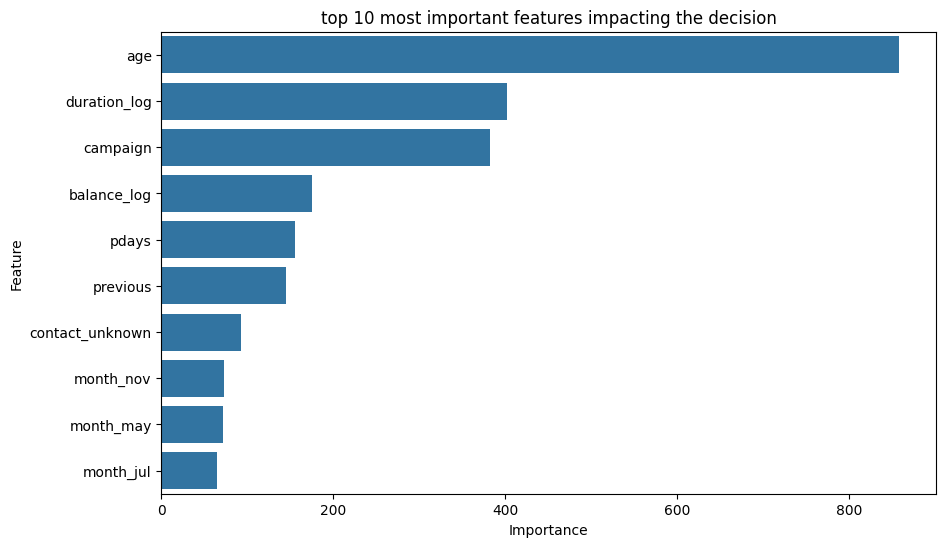

In [61]:
# Plotting top 10 most important features 
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title('top 10 most important features impacting the decision')
plt.show()